# **Flood Event Analysis for Nairobi**

Author: Stacy Mwangi
<br>Date: 2025-2026</br>

## Environmental Research Question: 

- What are the trends in fuel economy across different vehicle classes?
- How do different factors like engine size and vehicle weight affect fuel economy?

Link to GitHub repository: [GitHub Repository](<insert link here>)



## Loading Data
Relevant Lectures:
<br>**Course 1, Module 1**: "Getting to know Environmental Data" by Eli — Covers types and sources of data.</br>
<br>**Course 2, Module 5**: "Sources of Environmental Data" by Jess O'Toole — Discusses where to find free/accessible data sources.</br>

Loading flood parquet...



Reading layer `gadm41_KEN_2' from data source 
  `/home/user/Capstone-Project-Template/CRUM_Nairobi/data/raw_data/gadm41_KEN_2.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 300 features and 13 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 33.90959 ymin: -4.720417 xmax: 41.92622 ymax: 5.061166
Geodetic CRS:  WGS 84


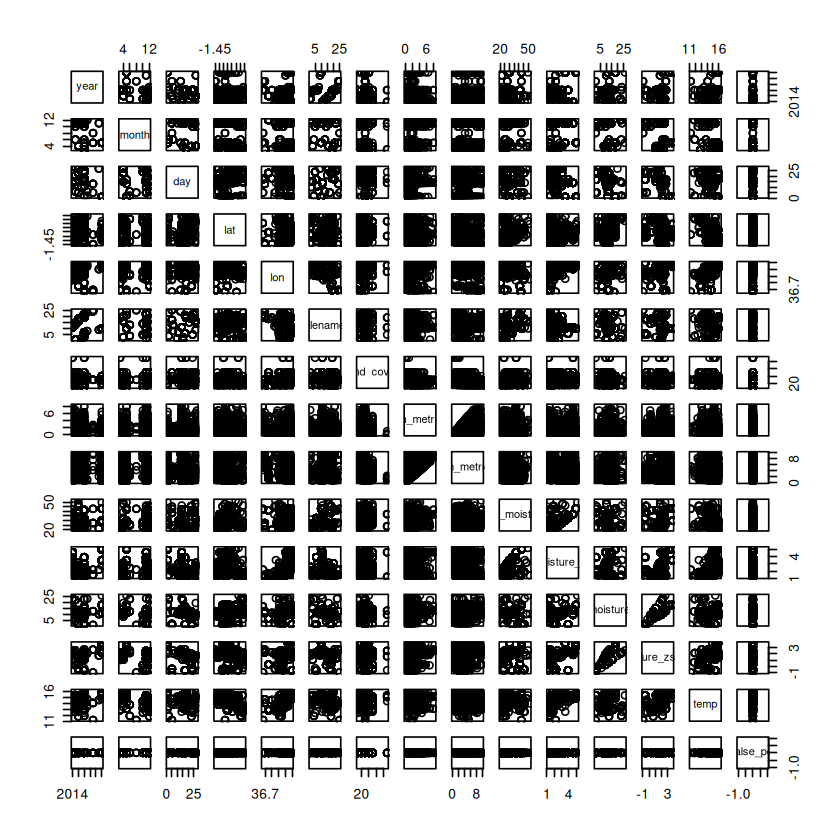

In [4]:
# Load libraries
library(tidyverse)
library(sf)
library(terra)
library(osmdata)
library(ggplot2)
library(MASS)       # for kde2d
library(scales)
library(patchwork)
library(ggspatial)
library(ggrepel)
library(cowplot)
library(arrow)      # for read_parquet()
library(ggnewscale)

setwd("/home/user/Capstone-Project-Template/CRUM_Nairobi/data")

# Nairobi bounding box (city extent)
nairobi_bbox <- c(
  xmin = 36.65, ymin = -1.45,
  xmax = 37.10, ymax = -1.10
)

# Colour palette 
COL_BG        <- "#F5EFE0"       # parchment
COL_FLOOD_LOW <- "#A8C5C0"       # pale teal
COL_FLOOD_MID <- "#3A7D8C"       # mid teal
COL_FLOOD_HI  <- "#0D3B52"       # deep navy (chronic)
COL_POP       <- "#D4622A"       # burnt orange for population
COL_ROAD      <- "#BFB9A8"       # muted warm grey roads
COL_ROAD_RISK <- "#E8C84A"       # amber - roads inside flood zone
COL_TEXT      <- "#2C2416"       # dark warm brown
COL_ACCENT    <- "#C0392B"       # red accent for callouts

# LOAD FLOOD DATA
# The dataset tile for Nairobi is S03E036.
# Download from HuggingFace:
#   https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/tree/main/S03/S03E036
#
# Expected file: S03/S03E036/S03E036-post-processing.parquet

PARQUET_PATH    <- "raw_data/flood_filtered.parquet"
# --- Load parquet flood detections ---
message("Loading flood parquet...")

flood_raw <- read_parquet(PARQUET_PATH)

# Crop to Nairobi extent
flood_nairobi <- flood_raw %>%
  filter(
    lon >= nairobi_bbox["xmin"], lon <= nairobi_bbox["xmax"],
    lat >= nairobi_bbox["ymin"], lat <= nairobi_bbox["ymax"]
  )

WORLDPOP_PATH   <- "raw_data/ken_pop_2026_CN_100m_R2025A_v1.tif"  # download from worldpop.org

# Load supplementary datasets
subcounties <- st_read("raw_data/gadm41_KEN_2.shp")%>% filter(NAME_1 == "Nairobi")

## Cleaning Data
Relevant Lectures:
<br>**Course 3, Module 10**: "Data Cleaning Pt. 1" and "Data Cleaning Pt. 2" by JRS — Introduces key principles and practical data-cleaning techniques in R.</br>
<br>**Course 3, Module 8**: "Using EDA to Clean Data" by Angel — Discusses identifying common issues in data and addressing them.</br>

In [0]:


# Apply recommended filters (reduces false positives for multi-year aggregation)
flood_filtered <- flood_nairobi %>%
  filter(
    dem_metric_2       < 10,
    soil_moisture_sca  > 1,
    soil_moisture_zscore > 1,
    soil_moisture      > 20,
    temp               > 0,
    land_cover         != 60,
    edge_false_positives == 0
  )
message(glue::glue("Flood detections after filtering: {nrow(flood_filtered)}"))


In [16]:
flood_filtered <- read_parquet("raw_data/flood_filtered.parquet")
# Count detections per unique lat/lon across full 10-year period
flood_recurrence <- flood_filtered %>%
  group_by(lat, lon) %>%
  summarise(
    n_months  = n_distinct(paste(year, month)),
    n_events  = n(),
    first_year = min(year),
    last_year  = max(year),
    .groups = "drop"
  ) %>%
  mutate(
    risk_class = case_when(
      n_months >= 6  ~ "Chronic (6+ months)",
      n_months >= 3  ~ "High (3–5 months)",
      n_months >= 1  ~ "Occasional (1–2 months)"
    ),
    risk_class = factor(risk_class, levels = c(
      "Occasional (1–2 months)", "High (3–5 months)", "Chronic (6+ months)"
    ))
  )

# Convert to sf
flood_sf <- st_as_sf(flood_recurrence,
                     coords = c("lon", "lat"),
                     crs = 4326)


# 2. COMPUTE KDE CONTOURS (the "rings")

message("Computing flood density contours...")

# Weight by recurrence months for contour intensity
kde_input <- flood_recurrence %>%
  # Repeat rows by n_months so chronic sites dominate the KDE
  uncount(n_months)

kde_fit <- kde2d(
  x    = kde_input$lon,
  y    = kde_input$lat,
  n    = 400,
  lims = c(nairobi_bbox["xmin"], nairobi_bbox["xmax"],
           nairobi_bbox["ymin"], nairobi_bbox["ymax"])
)

# Convert KDE to contour sf polygons
kde_df <- expand.grid(lon = kde_fit$x, lat = kde_fit$y) %>%
  mutate(density = as.vector(kde_fit$z))

# We'll use ggplot's stat_contour_filled for rendering (cleaner)
# Store kde_df for plotting

# 3. LOAD OSM ROADS

message("Fetching OSM roads for Nairobi...")

osm_query <- opq(bbox = c(
  nairobi_bbox["xmin"], nairobi_bbox["ymin"],
  nairobi_bbox["xmax"], nairobi_bbox["ymax"]
)) %>%
  add_osm_feature(key = "highway", value = c(
    "primary", "secondary", "tertiary",
    "residential", "unclassified", "living_street", "footway", "path"
  ))

osm_roads <- read_sf("raw_data/nairobi_roads.gpkg")
roads_lines <- osm_roads %>%
  dplyr::select(osm_id, name, highway,geom) %>%
  st_transform(4326)

# Classify road type
roads_lines <- roads_lines %>%
  mutate(road_class = case_when(
    highway %in% c("primary", "secondary")         ~ "Major",
    highway %in% c("tertiary", "residential",
                   "unclassified", "living_street") ~ "Local",
    highway %in% c("footway", "path")              ~ "Footpath",
    TRUE                                            ~ "Local"
  ))
message("Roads loaded and classified")

Computing flood density contours...



Fetching OSM roads for Nairobi...



Roads loaded and classified



## Exploratory Data Analysis (EDA)
Relevant Lectures:
<br>**Course 3, Module 9**: "Conducting Exploratory Data Analysis (EDA)" by JRS — Introduces how to explore relationships between variables and visualise data.</br>
<br>**Course 3, Module 10**: "Creating Data Visualizations for EDA" by JRS — Focuses on visualizing relationships between variables using linear regression and other plots.</br>

In [18]:

# 4. IDENTIFY ROADS AT FLOOD RISK

message("Intersecting roads with flood zones...")

# Buffer flood points by 80m (~0.0007 degrees) to create flood zone polygons
flood_buffer <- flood_sf %>%
  filter(n_months >= 0) %>%     # only high/chronic zones interrupt roads
  st_buffer(0.0007)             # ~80m

flood_union <- st_union(flood_buffer)

# Find road segments intersecting flood zones
roads_at_risk <- roads_lines %>%
  mutate(
    in_flood_zone = lengths(st_intersects(geom, flood_union)) > 0
  )


# 5. LOAD POPULATION RASTER
# Download WorldPop Kenya 2020 from: https://hub.worldpop.org/geodata/listing?id=29786
# File: ken_ppp_2020_1km_Aggregated.tif  (or 100m version)

message("Loading WorldPop population raster...")

pop_rast <- rast(WORLDPOP_PATH)

# Crop to Nairobi
nairobi_ext <- ext(
  nairobi_bbox["xmin"], nairobi_bbox["xmax"],
  nairobi_bbox["ymin"], nairobi_bbox["ymax"]
)
pop_crop <- crop(pop_rast, nairobi_ext)

# Convert to data frame for ggplot
pop_df <- as.data.frame(pop_crop, xy = TRUE) %>%
  rename(lon = x, lat = y, population = 3) %>%
  filter(!is.na(population), population > 0) %>%
  mutate(population = pmin(population, quantile(population, 0.99)))  # cap outliers
message("Loaded, cropped and converted to dataframe")

Intersecting roads with flood zones...



Loading WorldPop population raster...



Loaded, cropped and converted to dataframe



In [19]:
# 6. NEIGHBOURHOOD LABELS (Nairobi key areas)

# Key flood-vulnerable neighbourhoods for annotation
nairobi_labels <- tibble(
  name = c("Mathare", "Kibera", "Mukuru", "Kawangware",
           "Korogocho", "Ngong River/nCorridor", "Nairobi CBD"),
  lon  = c(36.857,   36.779,  36.873,  36.738,
            36.882,   36.800,  36.820),
  lat  = c(-1.256,   -1.312,  -1.305,  -1.283,
            -1.246,   -1.335,  -1.284)
)

labels_sf <- st_as_sf(nairobi_labels, coords = c("lon", "lat"), crs = 4326)


# 7. COMPUTE SUMMARY STATS FOR CALLOUTS


# People in chronic flood zones (n_months >= 6)
chronic_buffer <- flood_sf %>%
  filter(n_months >= 6) %>%
  st_buffer(0.0007) %>%
  st_union()

# Approximate from WorldPop
pop_sf <- st_as_sf(pop_df, coords = c("lon", "lat"), crs = 4326)
pop_in_chronic <- pop_sf %>%
  filter(lengths(st_intersects(geometry, chronic_buffer)) > 0) %>%
  pull(population) %>%
  sum(na.rm = TRUE)

# Roads at risk km
roads_risk_km <- roads_at_risk %>%
  filter(in_flood_zone) %>%
  st_length() %>%
  sum() %>%
  units::set_units("km") %>%
  round(0)

# Total flood events
total_events <- nrow(flood_filtered)

message(glue::glue(
  "People in chronic zones: ~{scales::comma(round(pop_in_chronic, -3))}
   Roads at risk: {roads_risk_km} km
   Total flood detections: {scales::comma(total_events)}"
))

# 8. SEASONALITY STRIP (monthly flood frequency)

season_df <- flood_filtered %>%
  count(month) %>%
  mutate(
    month_name = month.abb[month],
    month_name = factor(month_name, levels = month.abb),
    pct        = n / sum(n)
  )

plot_season <- ggplot(season_df, aes(x = month_name, y = pct)) +
  geom_col(fill = COL_FLOOD_MID, width = 0.7) +
  geom_col(
    data = season_df %>% filter(month %in% c(3, 4, 5, 10, 11)),
    fill = COL_FLOOD_HI, width = 0.7
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title    = "WHEN FLOODS STRIKE",
    subtitle = "Monthly share of flood detections, 2014–2024",
    x = NULL, y = NULL
  ) +
  theme_minimal(base_family = "sans") +
  theme(
    plot.background  = element_rect(fill = COL_BG, colour = NA),
    panel.background = element_rect(fill = COL_BG, colour = NA),
    panel.grid.major.x = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_line(colour = "#D9D0BC", linewidth = 0.3),
    plot.title    = element_text(size = 9,  face = "bold",  colour = COL_TEXT, hjust = 0),
    plot.subtitle = element_text(size = 7,  colour = COL_TEXT, hjust = 0),
    axis.text     = element_text(size = 7,  colour = COL_TEXT),
    plot.margin   = margin(8, 12, 8, 12)
  )

People in chronic zones: ~0
Roads at risk: 0 km
Total flood detections: 4,481



## Final Analysis and Visualizations

<br>*Export a minimum of 2 visualizations (PDF, PNG or JPG). Each visualization should have a title, labeled x and y axis.* </br>

Relevant Lectures:
<br>**Course 3, Module 9**: "Helpful Data Visualizations for Data Cleaning and EDA" by JRS — Introduces helpful visualizations for EDA step.</br>
<br>**Course 5, Module 17**: "Data Visualizations and Communication" by Simon Queenborough — Discusses effective data visualization techniques.</br>



In [21]:
# 9. MAIN MAP

message("Building main map...")

# KDE density breaks — adjust after inspecting your data
# These quantile breaks define the contour ring thresholds
dens_breaks <- quantile(kde_df$density[kde_df$density > 0],
                        probs = c(0.60, 0.75, 0.88, 0.95, 0.99),
                        na.rm = TRUE)

main_map <- ggplot() +

  # --- Population density (warm amber glow beneath everything) ---
  geom_raster(
    data = pop_df,
    aes(x = lon, y = lat, fill = population),
    alpha = 0.55
  ) +
  scale_fill_gradient(
    low  = "transparent",
    high = COL_POP,
    na.value = "transparent",
    name = "Population/ndensity",
    guide = guide_colourbar(
      title.position = "top",
      barwidth = 0.5, barheight = 3,
      ticks = FALSE
    )
  ) +

  # --- Flood recurrence contour rings ---
  # (new scale so we use ggnewscale or manual approach)
  # We use stat_contour_filled on kde_df density
  new_scale_fill() +   # requires ggnewscale package
  stat_contour_filled(
    data    = kde_df,
    aes(x = lon, y = lat, z = density, fill = after_stat(level)),
    breaks  = c(0, dens_breaks),
    alpha   = 0.72
  ) +
  scale_fill_manual(
    values = c(
      "transparent",
      alpha(COL_FLOOD_LOW, 0.5),
      alpha(COL_FLOOD_MID, 0.6),
      alpha(COL_FLOOD_MID, 0.75),
      alpha(COL_FLOOD_HI,  0.85),
      alpha(COL_FLOOD_HI,  0.95)
    ),
    name   = "Flood recurrence/n(2014–2024)",
    labels = c("None", "Occasional", "", "High", "", "Chronic"),
    guide  = guide_legend(
      title.position = "top",
      override.aes   = list(alpha = 1)
    )
  ) +

  # --- Contour ring outlines (the "rings of risk" effect) ---
  stat_contour(
    data      = kde_df,
    aes(x = lon, y = lat, z = density),
    breaks    = dens_breaks,
    colour    = "white",
    linewidth = 0.25,
    alpha     = 0.6,
    linetype  = "solid"
  ) +

  # --- Roads — safe (outside flood zone) ---
  geom_sf(
    data      = roads_at_risk %>% filter(!in_flood_zone, road_class == "Major"),
    colour    = COL_ROAD,
    linewidth = 0.35,
    alpha     = 0.9
  ) +
  geom_sf(
    data      = roads_at_risk %>% filter(!in_flood_zone, road_class != "Major"),
    colour    = COL_ROAD,
    linewidth = 0.12,
    alpha     = 0.6
  ) +

  # --- Roads — AT RISK (inside flood zone) — rendered as dashed amber ---
  geom_sf(
    data      = roads_at_risk %>% filter(in_flood_zone, road_class == "Major"),
    colour    = COL_ROAD_RISK,
    linewidth = 0.5,
    linetype  = "dashed",
    alpha     = 1
  ) +
  geom_sf(
    data      = roads_at_risk %>% filter(in_flood_zone, road_class != "Major"),
    colour    = COL_ROAD_RISK,
    linewidth = 0.2,
    linetype  = "dashed",
    alpha     = 0.85
  ) +

  # --- Neighbourhood labels ---
  geom_label_repel(
    data         = nairobi_labels,
    aes(x = lon, y = lat, label = name),
    size         = 2.4,
    family       = "sans",
    colour       = COL_TEXT,
    fill         = alpha(COL_BG, 0.85),
    label.size   = 0,
    label.padding = unit(0.15, "lines"),
    segment.colour = COL_TEXT,
    segment.size = 0.3,
    min.segment.length = 0.2,
    box.padding  = 0.4,
    force        = 2,
    seed         = 42
  ) +

  # --- Map extent & coords ---
  coord_sf(
    xlim = c(nairobi_bbox["xmin"], nairobi_bbox["xmax"]),
    ylim = c(nairobi_bbox["ymin"], nairobi_bbox["ymax"]),
    expand = FALSE
  ) +

  # --- Scale bar & north arrow ---
  annotation_scale(
    location   = "bl",
    width_hint = 0.18,
    text_col   = COL_TEXT,
    line_col   = COL_TEXT,
    bar_cols   = c(COL_TEXT, COL_BG)
  ) +
  annotation_north_arrow(
    location = "bl",
    pad_x = unit(0.5, "cm"), pad_y = unit(0.7, "cm"),
    style = north_arrow_minimal(fill = COL_TEXT, line_col = COL_TEXT,
                                text_col = COL_TEXT, text_size = 7)
  ) +

  # --- Theme ---
  theme_void(base_family = "sans") +
  theme(
    plot.background  = element_rect(fill = COL_BG, colour = NA),
    panel.background = element_rect(fill = "#D6CCBA", colour = NA),
    legend.position  = c(0.02, 0.98),
    legend.justification = c(0, 1),
    legend.background = element_rect(fill = alpha(COL_BG, 0.85), colour = NA),
    legend.key.size   = unit(0.35, "cm"),
    legend.title      = element_text(size = 7,  face = "bold", colour = COL_TEXT),
    legend.text       = element_text(size = 6.5, colour = COL_TEXT),
    legend.margin     = margin(4, 6, 4, 6),
    legend.box.margin = margin(0, 0, 0, 0),
    plot.margin       = margin(0, 0, 0, 0)
  )

# 10. CALLOUT STAT BOXES

make_stat_box <- function(number, label, bg = COL_FLOOD_MID) {
  ggplot() +
    annotate("rect",
             xmin = 0, xmax = 1, ymin = 0, ymax = 1,
             fill = bg, colour = NA) +
    annotate("text",
             x = 0.5, y = 0.62, label = number,
             size = 7, fontface = "bold",
             colour = "white", family = "sans", hjust = 0.5) +
    annotate("text",
             x = 0.5, y = 0.25, label = label,
             size = 2.5, colour = "white",
             family = "sans", hjust = 0.5, lineheight = 1.1) +
    theme_void() +
    theme(plot.background = element_rect(fill = bg, colour = NA))
}

stat1 <- make_stat_box(
  scales::comma(round(pop_in_chronic, -3)),
  "people live inside/nchronic flood zones",
  bg = COL_FLOOD_HI
)

stat2 <- make_stat_box(
  as.character(roads_risk_km),
  "km of roads regularly/nunder flood threat",
  bg = COL_FLOOD_MID
)

stat3 <- make_stat_box(
  "10 yrs",
  "of Sentinel-1 SAR/nflood observations",
  bg = "#5C4033"
)

stats_row <- plot_grid(stat1, stat2, stat3, nrow = 1, rel_widths = c(1, 1, 1))

# 11. TITLE & SOURCE PANEL

title_panel <- ggplot() +
  theme_void() +
  theme(plot.background = element_rect(fill = COL_BG, colour = NA)) +
  annotate("text",
           x = 0.03, y = 0.80,
           label = "RINGS OF RISK",
           size = 11, fontface = "bold",
           colour = COL_TEXT, family = "sans", hjust = 0) +
  annotate("text",
           x = 0.03, y = 0.52,
           label = "Nairobi's flood hotspots and the walking routes they sever",
           size = 5, colour = COL_TEXT, family = "sans", hjust = 0) +
  annotate("text",
           x = 0.03, y = 0.28,
           label = paste0(
             "Contour rings show where flooding has been detected repeatedly over 10 years (2014–2024) ",
             "using cloud-penetrating/nSentinel-1 SAR satellite data. Amber dashed lines are road segments ",
             "falling inside high or chronic flood zones —/nroutes on which pedestrians and cyclists depend ",
             "daily, with no dedicated infrastructure to protect them."
           ),
           size = 2.8, colour = COL_TEXT, family = "sans", hjust = 0,
           lineheight = 1.35) +
  annotate("text",
           x = 0.03, y = 0.05,
           label = paste0(
             "Sources: AI for Good Lab / Microsoft Flood Dataset (Nature Communications, 2025)  •  ",
             "OpenStreetMap  •  WorldPop Kenya 2020/n",
             "Methodology: Flood detections filtered for false positives (slope, soil moisture, temperature, land cover). ",
             "KDE weighted by recurrence months. All roads assumed to carry pedestrian & cyclist traffic."
           ),
           size = 2.2, colour = alpha(COL_TEXT, 0.65),
           family = "sans", hjust = 0, lineheight = 1.3) +
  xlim(0, 1) + ylim(0, 1)

# 12. LEGEND STRIP — road types

road_legend <- ggplot() +
  theme_void() +
  theme(plot.background = element_rect(fill = COL_BG, colour = NA)) +
  annotate("segment",
           x = 0.05, xend = 0.22, y = 0.65, yend = 0.65,
           colour = COL_ROAD, linewidth = 0.8) +
  annotate("text",
           x = 0.25, y = 0.65, label = "Road — no flood risk",
           size = 2.6, colour = COL_TEXT, hjust = 0) +
  annotate("segment",
           x = 0.05, xend = 0.22, y = 0.35, yend = 0.35,
           colour = COL_ROAD_RISK, linewidth = 0.8, linetype = "dashed") +
  annotate("text",
           x = 0.25, y = 0.35, label = "Road — inside flood zone",
           size = 2.6, colour = COL_TEXT, hjust = 0) +
  xlim(0, 1) + ylim(0, 1)

# 13. ASSEMBLE FULL POSTER

message("Assembling poster...")

# Require ggnewscale for dual fill scales in main map
# install.packages("ggnewscale") if not present

top_panel    <- plot_grid(title_panel, road_legend,
                          nrow = 1, rel_widths = c(3, 1))
bottom_panel <- plot_grid(stats_row, plot_season,
                          nrow = 1, rel_widths = c(1.2, 1))

full_poster <- plot_grid(
  top_panel,
  main_map,
  bottom_panel,
  ncol        = 1,
  rel_heights = c(0.18, 0.62, 0.20)
)

# 14. SAVE

output_path <- "outputs/rings_of_risk_nairobi.png"
message(glue::glue("Saving to {output_path}..."))

ggsave(
  filename = output_path,
  plot     = full_poster,
  width    = 14,
  height   = 17,
  dpi      = 300,
  bg       = COL_BG
)

message("Done! Open rings_of_risk_nairobi.png")


# APPENDIX: PACKAGE INSTALL BLOCK (run once before the script above)

# install.packages(c(
#   "tidyverse", "sf", "terra", "osmdata", "MASS",
#   "scales", "patchwork", "ggspatial", "ggrepel",
#   "cowplot", "arrow", "ggnewscale", "glue", "units"
# ))
#
# WorldPop download:
#   https://hub.worldpop.org/geodata/listing?id=29786
#   → Kenya 2020, unconstrained, 100m: KEN_ppp_v2b_2020_UNadj.tif
#
# Flood tile:
#   https://huggingface.co/datasets/ai-for-good-lab/ai4g-flood-dataset/tree/main
#   → Folder: S03/S03E036/
#   → Files needed:
#       S03E036-post-processing.parquet
#       S03E036-recurrence-80m-buffer.tif


Building main map...



Assembling poster...



Saving to outputs/rings_of_risk_nairobi.png...



Done! Open rings_of_risk_nairobi.png



## Ethical Considerations
- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

## Acknowledging Limitations
*In 1-2 sentences, acknowledge any limitations of your data or analysis.*

Relevant Lectures:
<br>**Course 3, Module 8**: "Handling Data Anomalies" by Angel — Discusses how to handle data anomalies and understand the limitations of your data.</br>

The analysis is based on the `mpg` dataset, which may have limitations such as:
- Limited scope: Only includes data available and may not capture the entire spectrum of vehicle data.
- Data quality: Possible measurement errors or missing values.

## Results for Non-Technical Audience
*In 1-2 sentences, explain the results of your analysis to a non-technical audience and the implications of your results for your environmental topic.*

Relevant Lectures:
<br>**Course 5, Module 15**: "Turning Data into Action" by Denice Ross — Discusses strategies for communicating results to a non-technical audience.</br>

Fuel economy varies significantly across different vehicle classes. Smaller and more efficient engines generally achieve higher miles per gallon (MPG) on the highway. Manufacturers show varying performance in terms of fuel economy, with some focusing on more efficient vehicles.

## Instructions for Reproducing Project
*Describe the steps someone else would need to take to reproduce your project.*
Relevant Lectures:
<br>**Course 2, Module 6**: "Addressing Version Control and Reproducibility" by Mitch — Explains the importance and strategies for version control.</br>
<br>**Course 4, Module 14**: "Creating Data Visualizations for EDA" by JRS — Provides guidance on reproducible EDA practices.</br>

1. Clone the GitHub repository.
2. Ensure you have R and the required libraries installed (`dplyr`, `ggplot2`).
3. Open and run the provided Jupyter notebook.